In [1]:
import spd
import spd.utils.visualization as vsd
import spd.initial_conditions as ic
from spd.sdfb_simulator import SPD_Simulator
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

try:
    import cupy as cp
except ModuleNotFoundError:
    cp = None

mpl.rcParams['font.size'] = 15

In [2]:
if cp is None:
    print("cupy not available; running on CPU only")
else:
    for i in range(cp.cuda.runtime.getDeviceCount()):
        cp.cuda.runtime.setDevice(i)
        print([f"{round(x/1E9,2)}GB" for x in cp.cuda.runtime.memGetInfo()])

cupy not available; running on CPU only


In [3]:
backend = "cupy" if cp is not None else "numpy"
gpu = True if cp is not None else False
print(f"backend: {backend}")
if cp is None:
    print("note: use_cupy=True will fall back to numpy")

backend: numpy
note: use_cupy=True will fall back to numpy


/Users/jonathan/Desktop/spd/spd/finite_volume/muscl.py:33: RuntimeWarning: divide by zero encountered in divide
  ratio = SlopeR/SlopeL
/Users/jonathan/Desktop/spd/spd/finite_volume/muscl.py:33: RuntimeWarning: invalid value encountered in divide
  ratio = SlopeR/SlopeL


t=0.2, steps taken 187, time taken 0.551, bzcps = 0.001


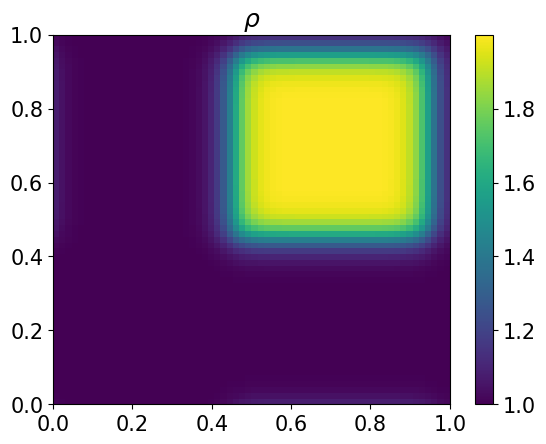

In [4]:
NDOF=128
p=1
N = NDOF//(p+1)
s = SPD_Simulator(p=p,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True,
                    time_integrator="rk4",
                    fallback="MUSCL",
                    scheme="FV")
s.perform_time_evolution(.2)
vsd.plot_field(s,s.dm.W_cv,0)

t=0.2, steps taken 191, time taken 2.614, bzcps = 0.001


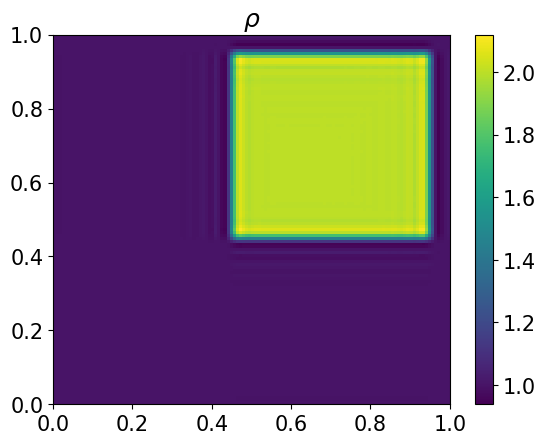

In [5]:
NDOF=128
p=3
N = NDOF//(p+1)
s = SPD_Simulator(p=3,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True,
                    time_integrator="rk4",
                    fallback="MUSCL",
                    scheme="SD")
s.perform_time_evolution(.2)
vsd.plot_field(s,s.dm.W_cv,0)

t=0.2, steps taken 191, time taken 6.335, bzcps = 0.0


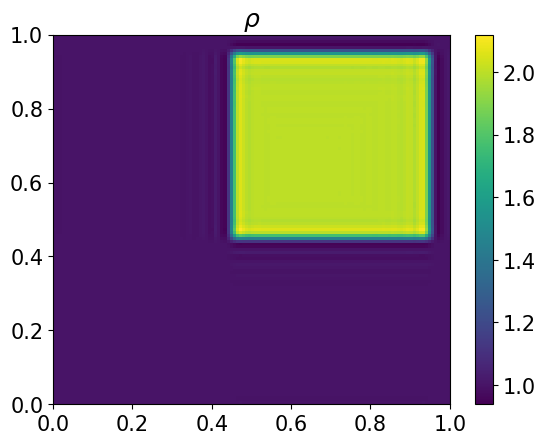

In [6]:
NDOF=128
p=3
N = NDOF//(p+1)
s = SPD_Simulator(p=3,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True,
                    fallback="MUSCL",
                    scheme="SD")
s.perform_time_evolution(.2)
vsd.plot_field(s,s.dm.W_cv,0)

/Users/jonathan/Desktop/spd/spd/trouble_detection.py:173: RuntimeWarning: divide by zero encountered in divide
  -np.where(dv < 0, np.where(vL > 0, vL, 0), np.where(vL < 0, vL, 0)) / dv
/Users/jonathan/Desktop/spd/spd/trouble_detection.py:173: RuntimeWarning: invalid value encountered in divide
  -np.where(dv < 0, np.where(vL > 0, vL, 0), np.where(vL < 0, vL, 0)) / dv
/Users/jonathan/Desktop/spd/spd/trouble_detection.py:180: RuntimeWarning: divide by zero encountered in divide
  alphaR = np.where(dv > 0, np.where(vR > 0, vR, 0), np.where(vR < 0, vR, 0)) / dv
/Users/jonathan/Desktop/spd/spd/trouble_detection.py:180: RuntimeWarning: invalid value encountered in divide
  alphaR = np.where(dv > 0, np.where(vR > 0, vR, 0), np.where(vR < 0, vR, 0)) / dv


t=0.2, steps taken 187, time taken 10.873, bzcps = 0.0


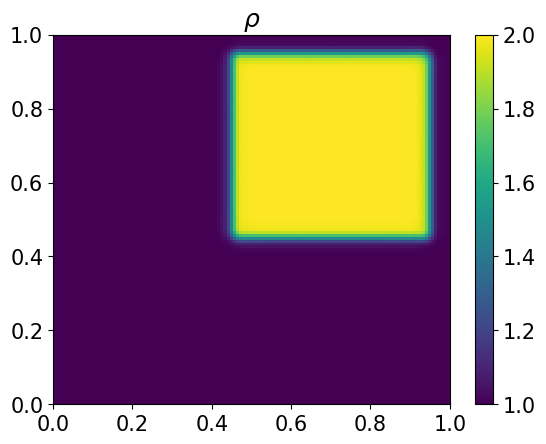

In [7]:
NDOF=128
p=3
N = NDOF//(p+1)
s = SPD_Simulator(p=3,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True,
                    time_integrator="rk4",
                    fallback="MUSCL",
                    scheme="SDFB")
s.perform_time_evolution(.2)
vsd.plot_field(s,s.dm.W_cv,0)

t=0.2, steps taken 140, time taken 0.133, bzcps = 0.004


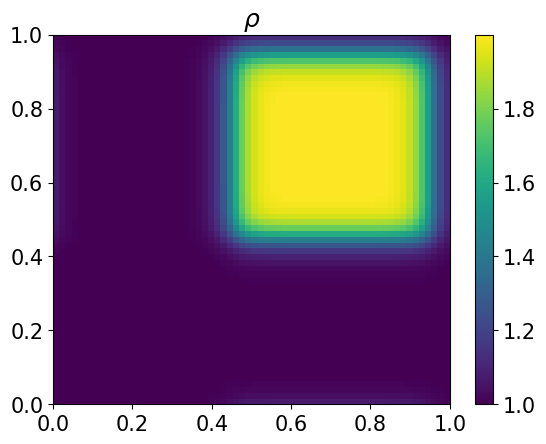

In [8]:
NDOF=128
p=1
N = NDOF//(p+1)
s = SPD_Simulator(p=p,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.8,use_cupy=True,
                    time_integrator="rk1",
                    fallback="MUSCL-Hancock",
                    scheme="FV")
s.perform_time_evolution(.2)
vsd.plot_field(s,s.dm.W_cv,0)

t=0.2, steps taken 140, time taken 0.079, bzcps = 0.002


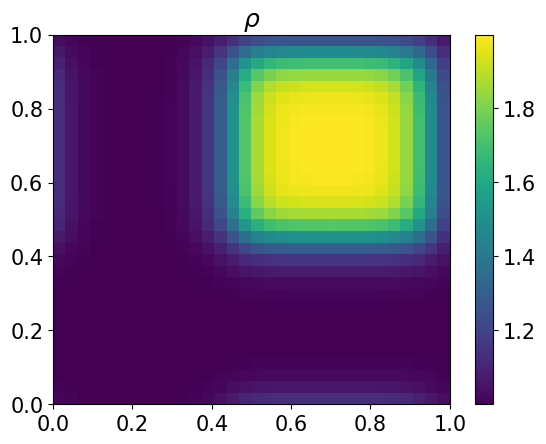

In [9]:
NDOF=128
p=3
N = NDOF//(p+1)
s = SPD_Simulator(p=p,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.8,use_cupy=True,
                    time_integrator="rk1",
                    fallback="MUSCL-Hancock",
                    scheme="FV")
s.perform_time_evolution(.2)
vsd.plot_field(s,s.dm.W_cv,0)

/Users/jonathan/Desktop/spd/spd/finite_volume/muscl.py:33: RuntimeWarning: divide by zero encountered in divide
  ratio = SlopeR/SlopeL
/Users/jonathan/Desktop/spd/spd/finite_volume/muscl.py:33: RuntimeWarning: invalid value encountered in divide
  ratio = SlopeR/SlopeL


t=0.2, steps taken 140, time taken 0.387, bzcps = 0.006


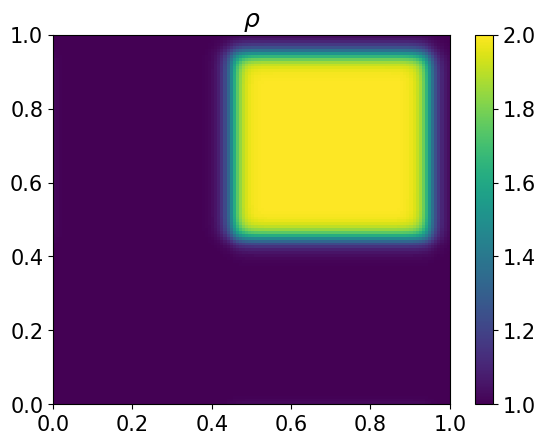

In [11]:
from spd.finite_volume.fv_simulator import FV_Simulator
NDOF=128
p=1
N = NDOF
s = FV_Simulator(p=p,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.8,use_cupy=True,
                     scheme="MUSCL-Hancock",time_integrator="rk1")
s.perform_time_evolution(.2)
vsd.plot_field(s,s.dm.W_cv,0)

t=1.0, steps taken 234, time taken 0.202, bzcps = 0.0


/Users/jonathan/Desktop/spd/spd/trouble_detection.py:173: RuntimeWarning: divide by zero encountered in divide
  -np.where(dv < 0, np.where(vL > 0, vL, 0), np.where(vL < 0, vL, 0)) / dv
/Users/jonathan/Desktop/spd/spd/trouble_detection.py:173: RuntimeWarning: invalid value encountered in divide
  -np.where(dv < 0, np.where(vL > 0, vL, 0), np.where(vL < 0, vL, 0)) / dv
/Users/jonathan/Desktop/spd/spd/trouble_detection.py:180: RuntimeWarning: divide by zero encountered in divide
  alphaR = np.where(dv > 0, np.where(vR > 0, vR, 0), np.where(vR < 0, vR, 0)) / dv
/Users/jonathan/Desktop/spd/spd/trouble_detection.py:180: RuntimeWarning: invalid value encountered in divide
  alphaR = np.where(dv > 0, np.where(vR > 0, vR, 0), np.where(vR < 0, vR, 0)) / dv


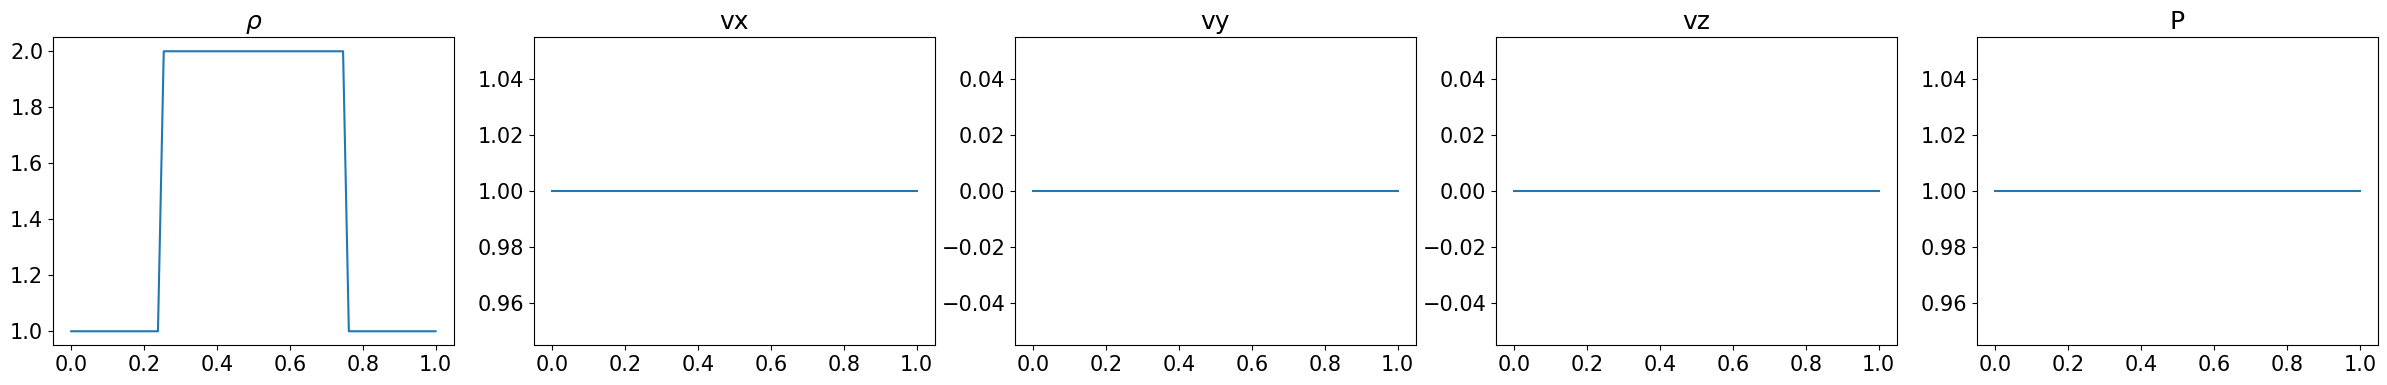

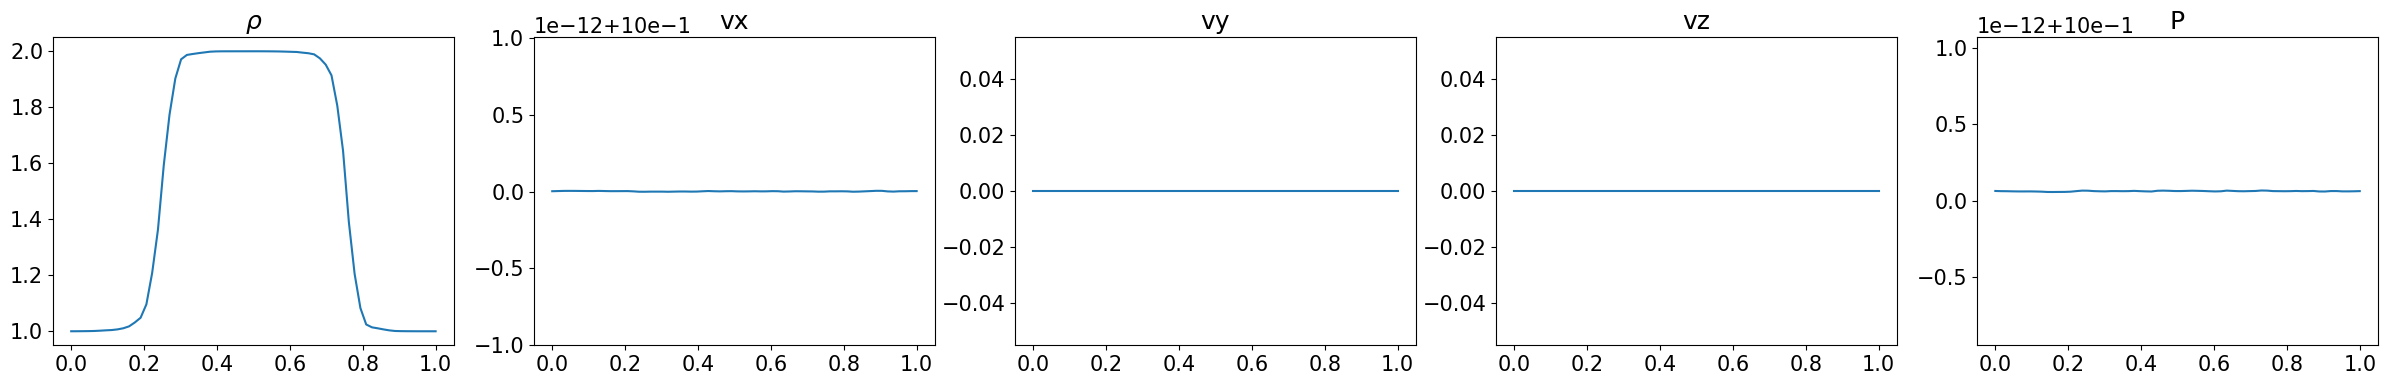

In [12]:
N=16
s = SPD_Simulator(p=3,N=(N,),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True,time_integrator="rk3")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

t=1.0, steps taken 88, time taken 0.012, bzcps = 0.0


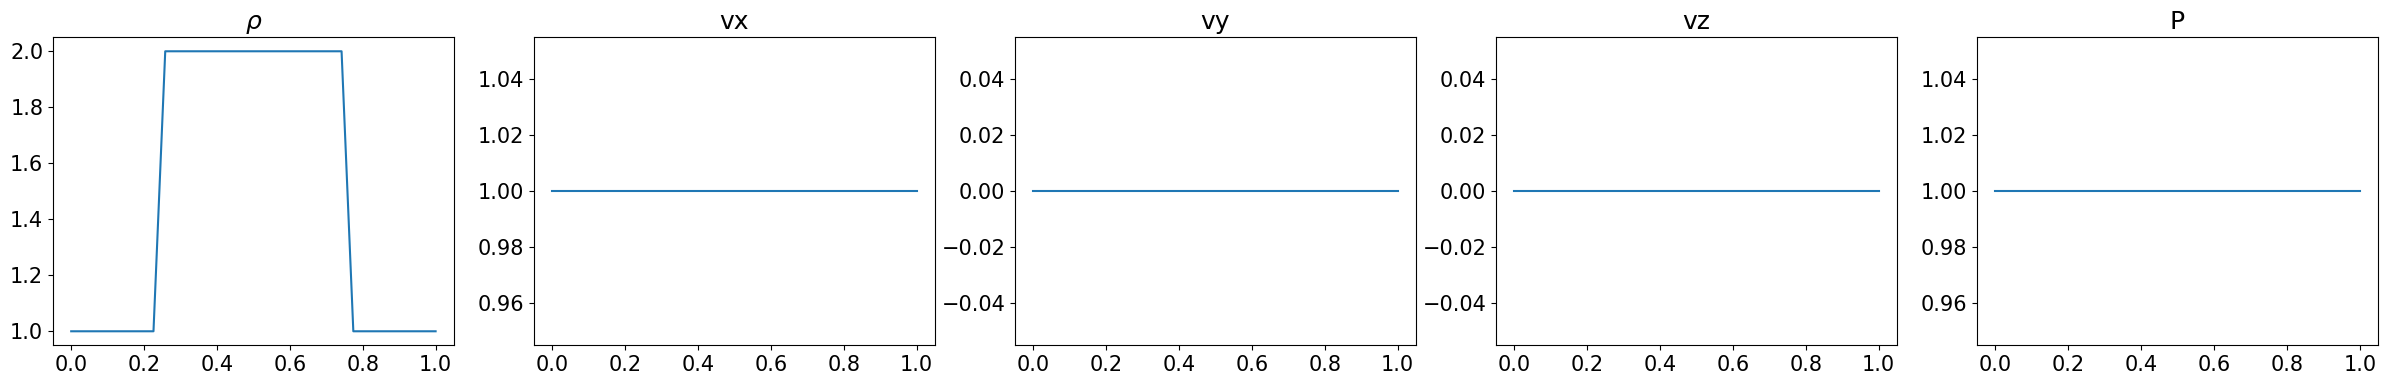

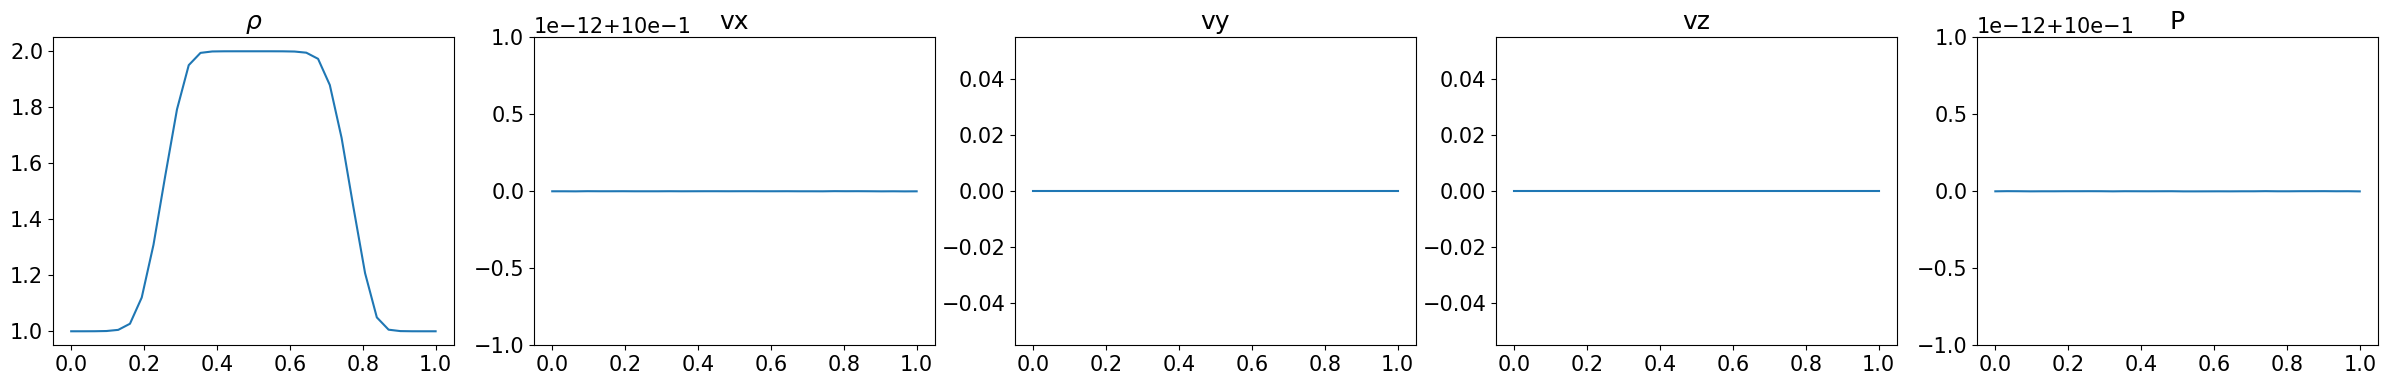

In [14]:
from spd.finite_volume.fv_simulator import FV_Simulator
N=32
s = FV_Simulator(p=1,N=(N,),init_fct=ic.step_function(),cfl_coeff=0.8,use_cupy=gpu,scheme="MUSCL-Hancock",time_integrator="rk1",
                 riemann_solver_fv="hllc", slope_limiter="moncen")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

t=1.0, steps taken 88, time taken 0.025, bzcps = 0.0


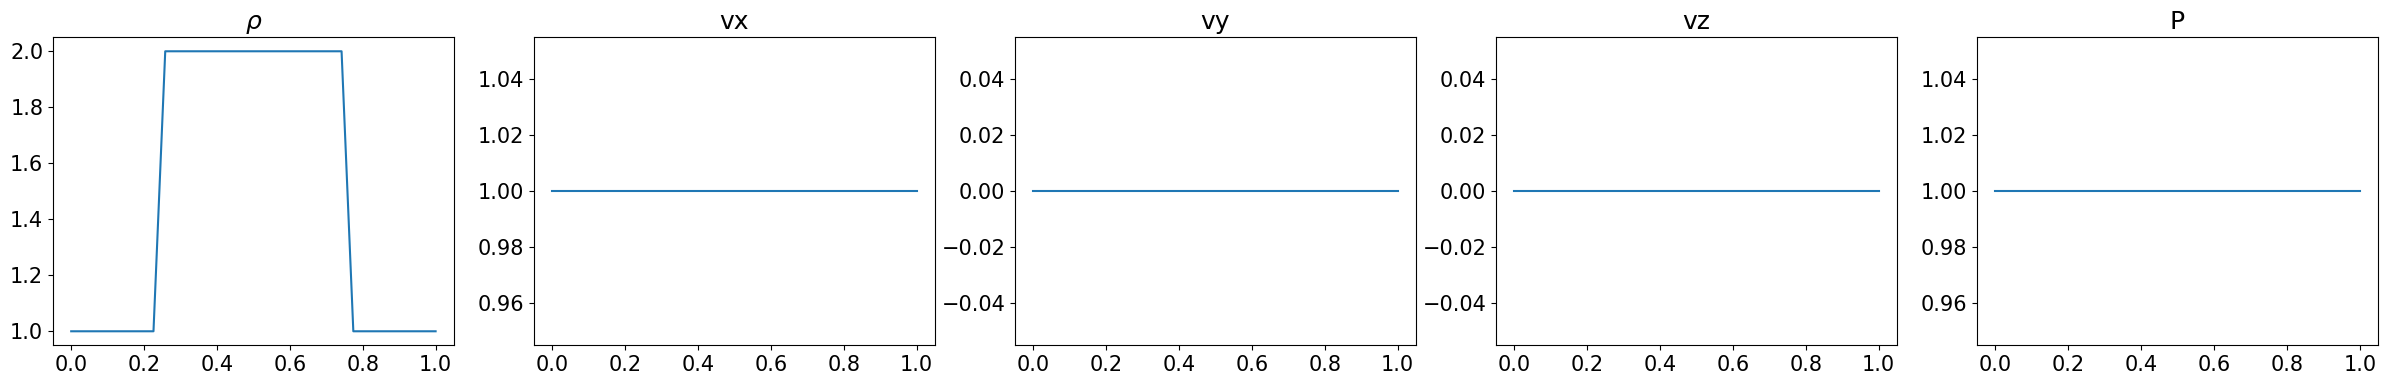

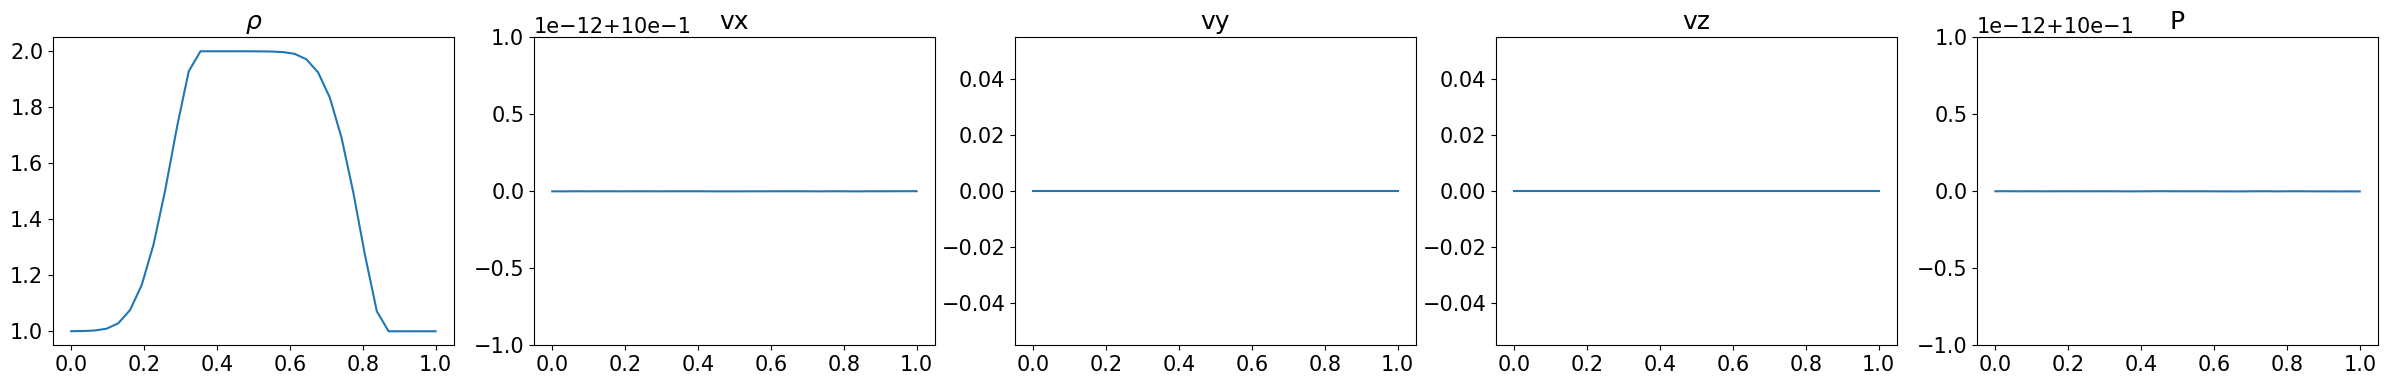

In [15]:
N=32
s = FV_Simulator(p=1,N=(N,),init_fct=ic.step_function(),cfl_coeff=0.8,use_cupy=True,scheme="MUSCL",time_integrator="rk2",
                riemann_solver_fv="hllc", slope_limiter="moncen")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

t=1.0, steps taken 88, time taken 0.035, bzcps = 0.0


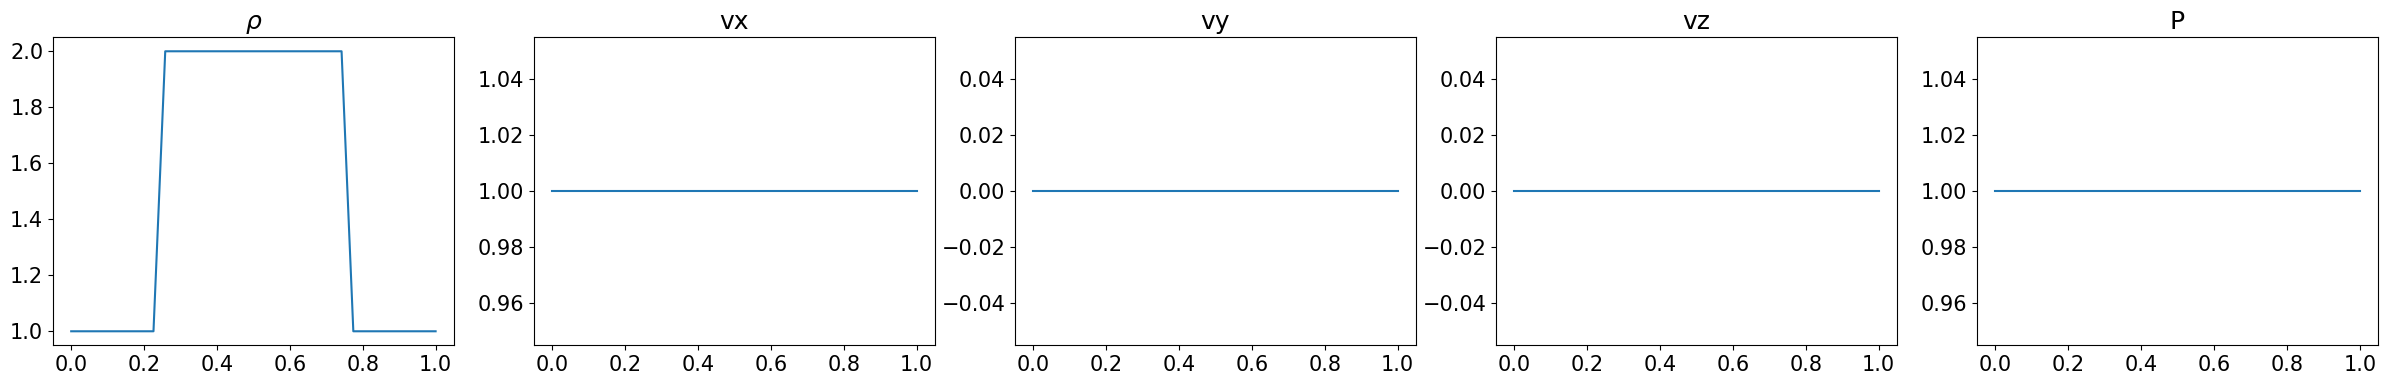

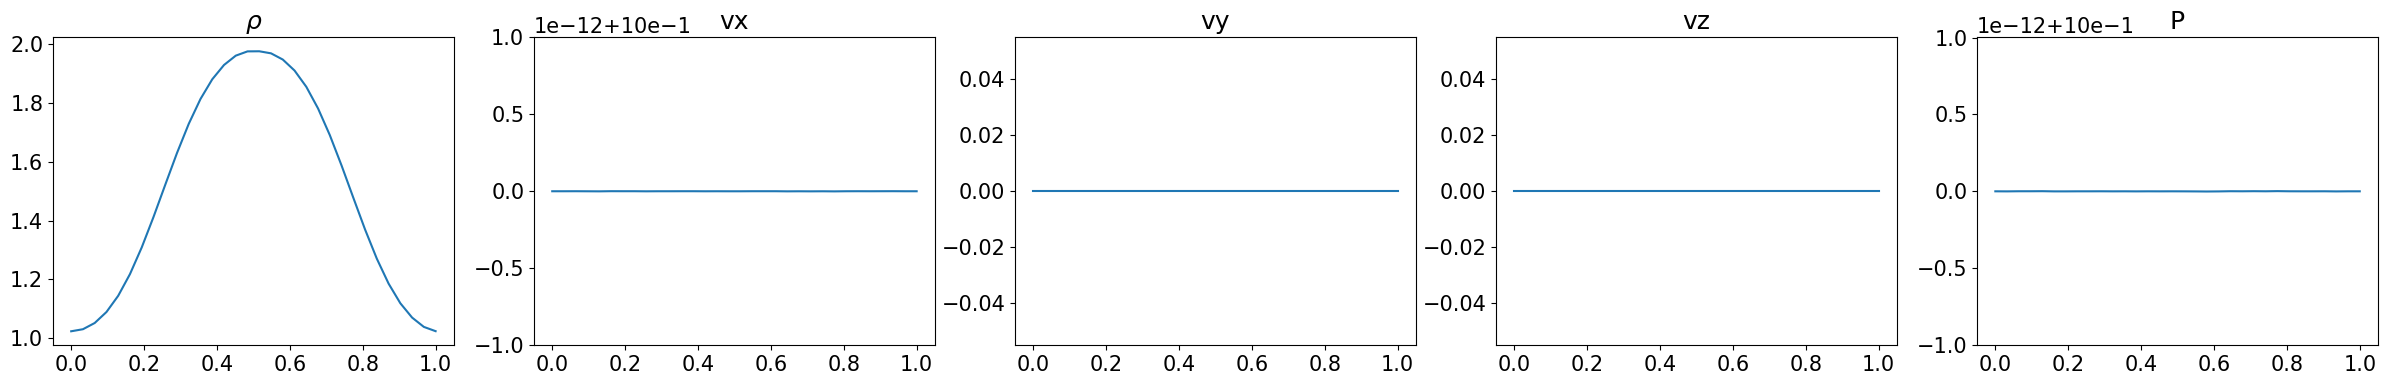

In [17]:
N=32
s = FV_Simulator(p=1,N=(N,),init_fct=ic.step_function(),cfl_coeff=0.8,use_cupy=True,scheme="MUSCL-Hancock",time_integrator="rk2",
                riemann_solver_fv="hllc", slope_limiter="moncen")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

t=1.0, steps taken 88, time taken 0.023, bzcps = 0.0


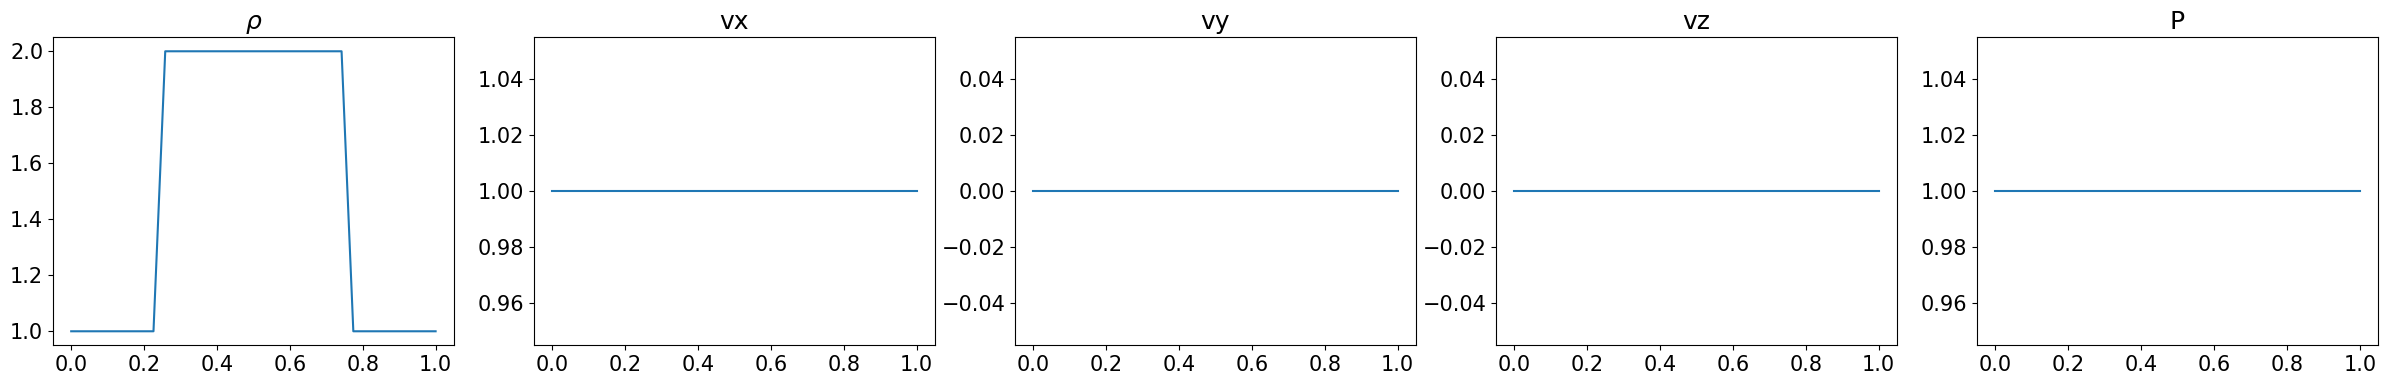

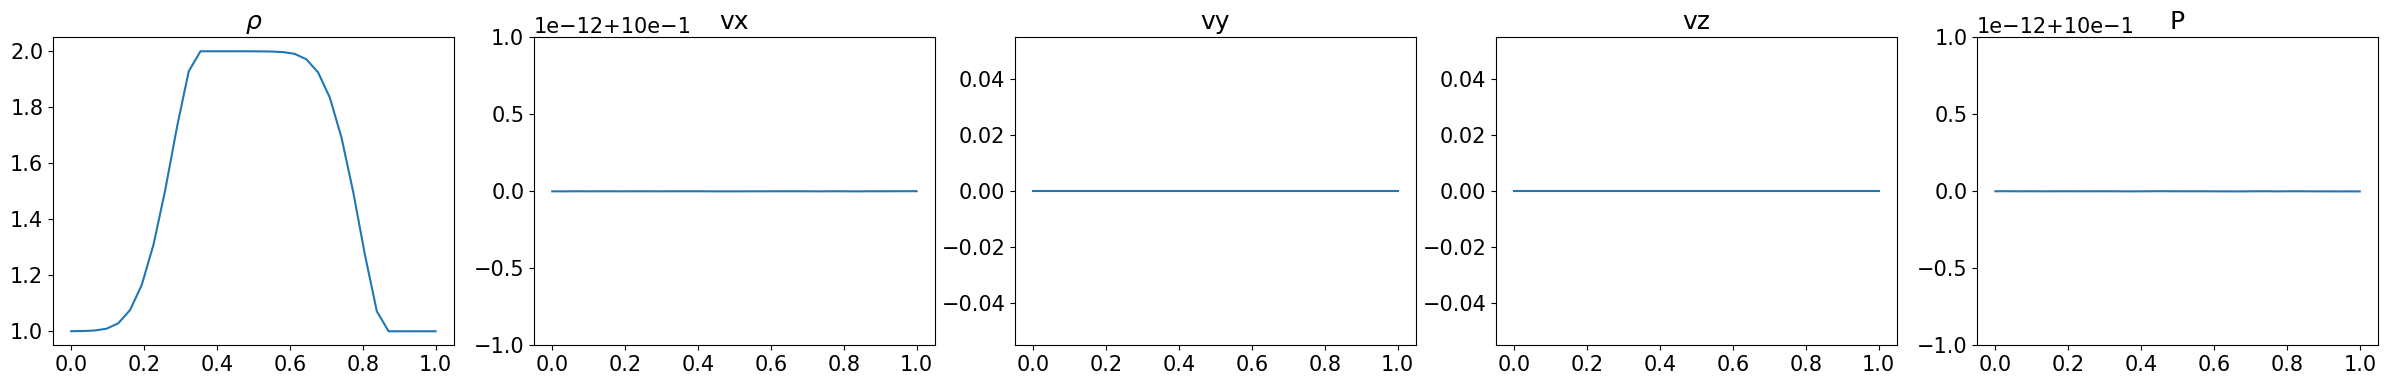

In [18]:
N=32
s = FV_Simulator(p=1,N=(N,),init_fct=ic.step_function(),cfl_coeff=0.8,use_cupy=True,scheme="MUSCL",time_integrator="rk2",
                riemann_solver_fv="hllc", slope_limiter="moncen")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

t=1.0, steps taken 350, time taken 0.774, bzcps = 0.002


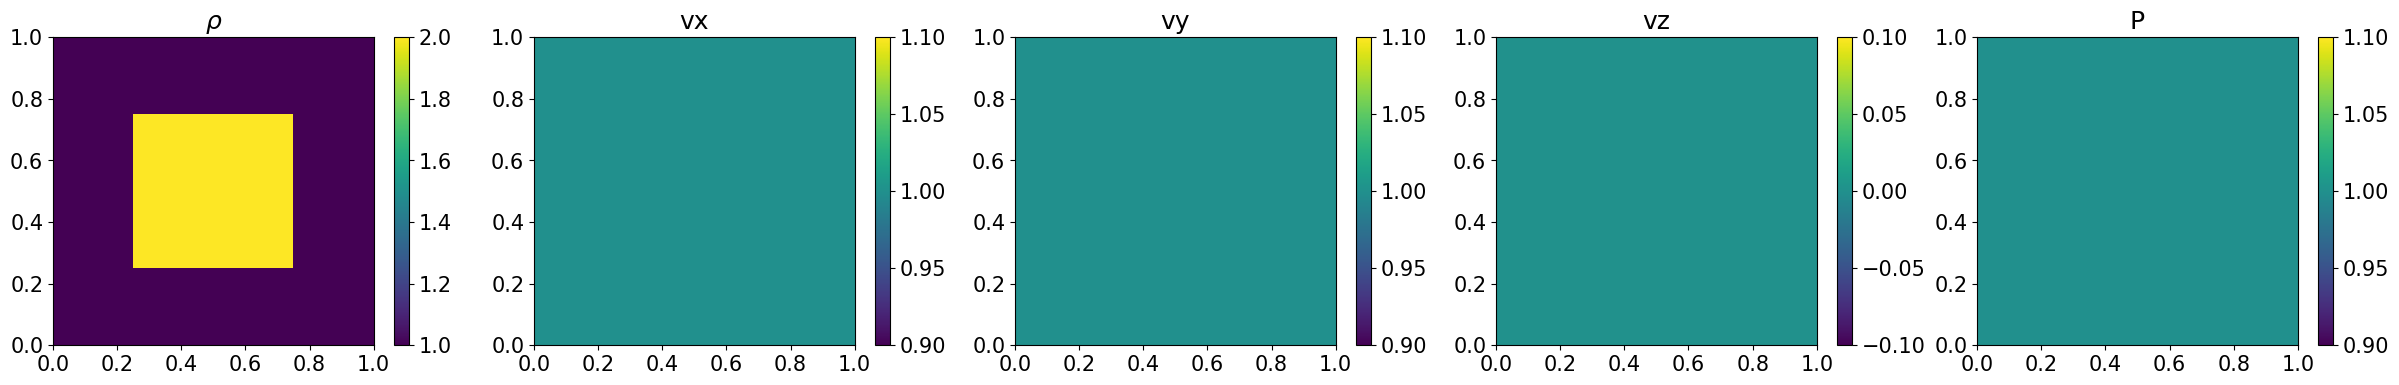

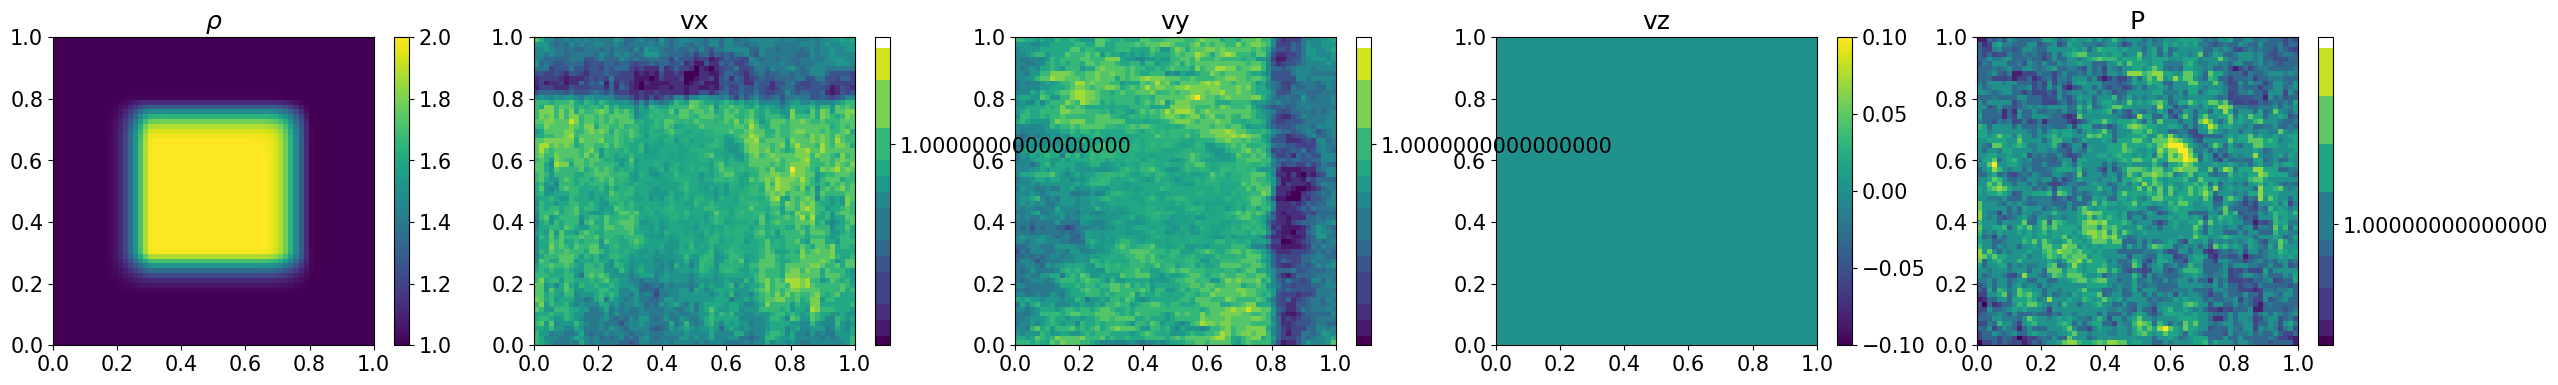

In [19]:
N=64
s = FV_Simulator(p=1,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.8,use_cupy=True,scheme="MUSCL",time_integrator="rk2",
                riemann_solver_fv="hllc", slope_limiter="moncen")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

t=1.0, steps taken 350, time taken 3.980203094892204


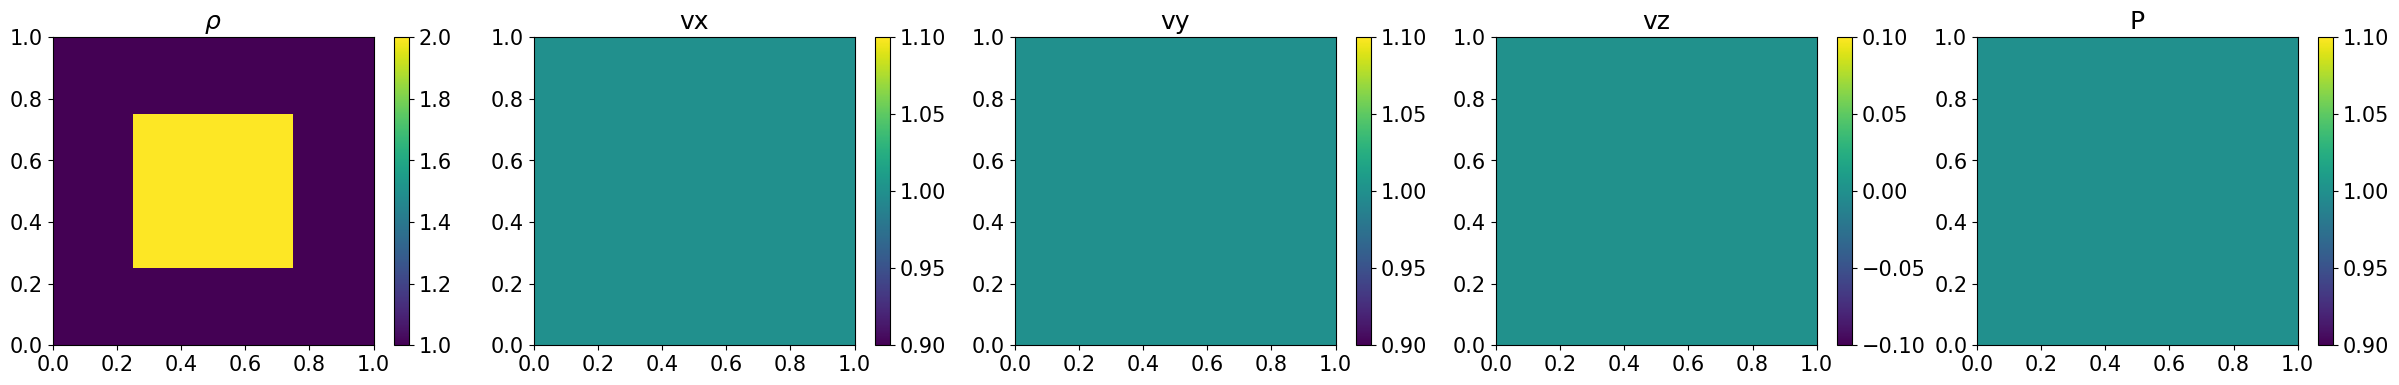

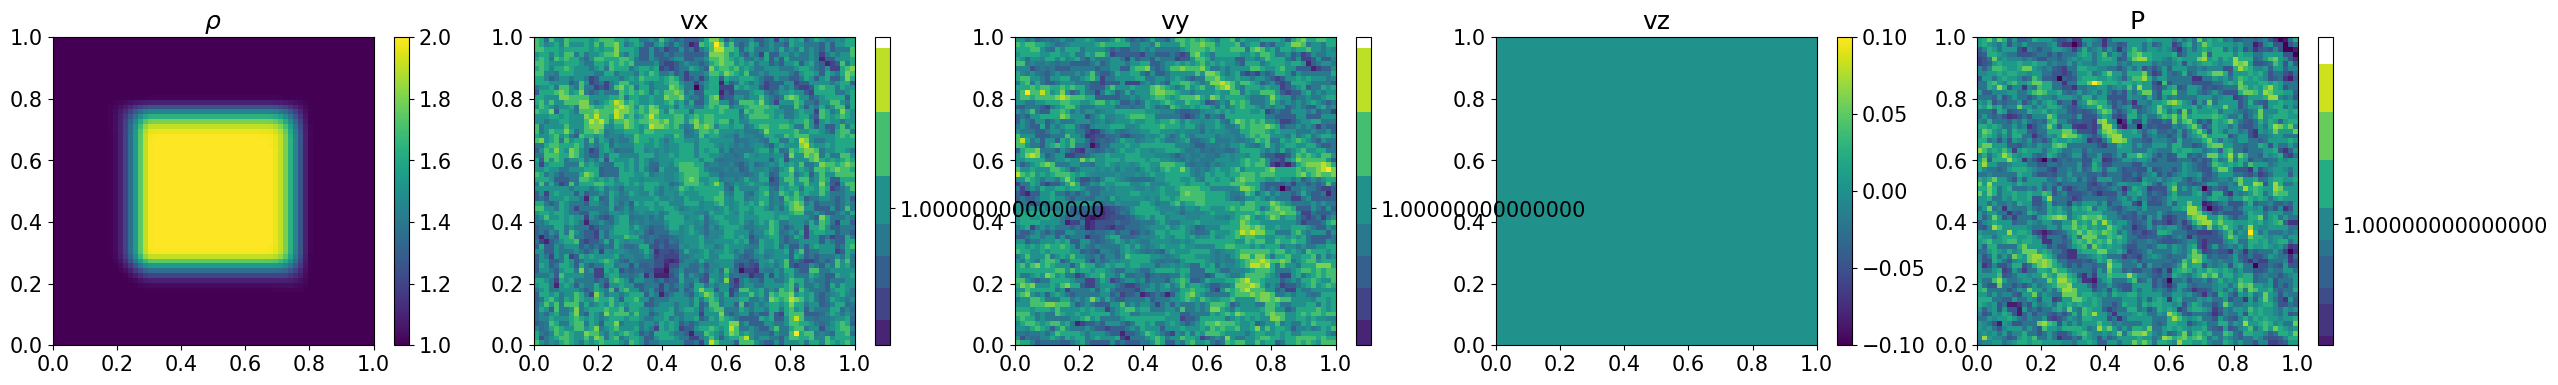

In [18]:
N=64
s = FV_Simulator(p=1,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.8,use_cupy=True,scheme="MUSCL-Hancock",time_integrator="rk1",
                riemann_solver_fv="hllc", slope_limiter="moncen")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

In [21]:
N=32
s = SDFB_Simulator(p=3,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True,time_integrator="ader")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

NameError: name 'SDFB_Simulator' is not defined

In [ ]:
N=32
s = SDFB_Simulator(p=1,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True,time_integrator="ader")
s.perform_iterations(1)
W = s.regular_mesh(s.dm.W_cv)
W = s.transpose_to_fv(W)
tr = s.lo_scheme.dm.troubles
W = np.where(tr==1,np.nan,W)
vsd.plot_field(s,W,0,regular=False,transpose=False)

In [ ]:
N=32
s = SDFB_Simulator(p=1,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True,time_integrator="rk2")
s.perform_iterations(1)
W = s.regular_mesh(s.dm.W_cv)
W = s.transpose_to_fv(W)
tr = s.lo_scheme.dm.troubles
W = np.where(tr==1,np.nan,W)
vsd.plot_field(s,W,0,regular=False,transpose=False)

In [22]:
K = s.regular_mesh(s.lo_scheme.dm.K_1)
K = s.transpose_to_fv(K)
vsd.plot_field(s,K,0,regular=False,transpose=False)

RecursionError: maximum recursion depth exceeded

In [23]:
N=32
s = FV_Simulator(p=1,N=(N,),init_fct=ic.step_function(),cfl_coeff=0.8,use_cupy=True,time_integrator="ader",m=0,
                riemann_solver_fv="hllc", slope_limiter="moncen")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

RecursionError: maximum recursion depth exceeded

# SD

Baseline SD runs using the default ADER time integration.

In [24]:
from spd.spectral_difference.sd_simulator import SD_Simulator

In [25]:
N=32
s = SD_Simulator(p=3,N=(N,),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True)
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

RecursionError: maximum recursion depth exceeded

## RK Examples

Explicit RK time integration for SD updates (rk3/rk4 examples).

t=1.0, steps taken 474, time taken 0.107, bzcps = 0.001


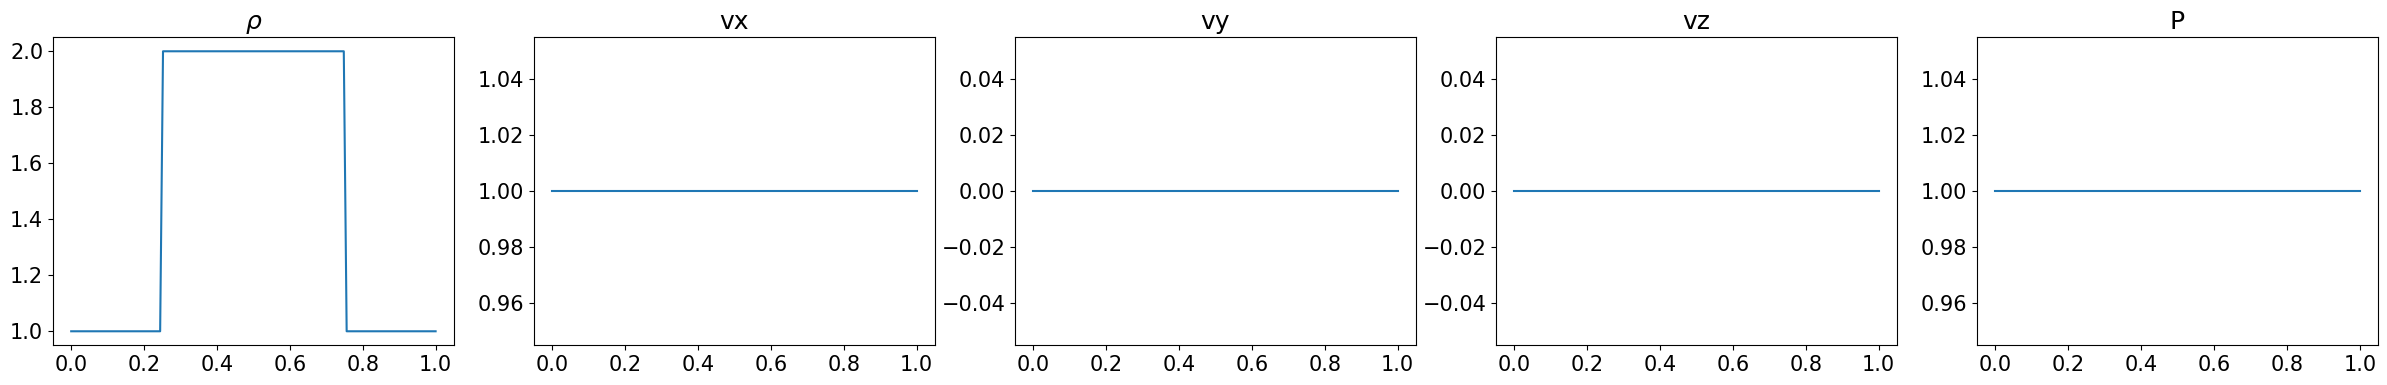

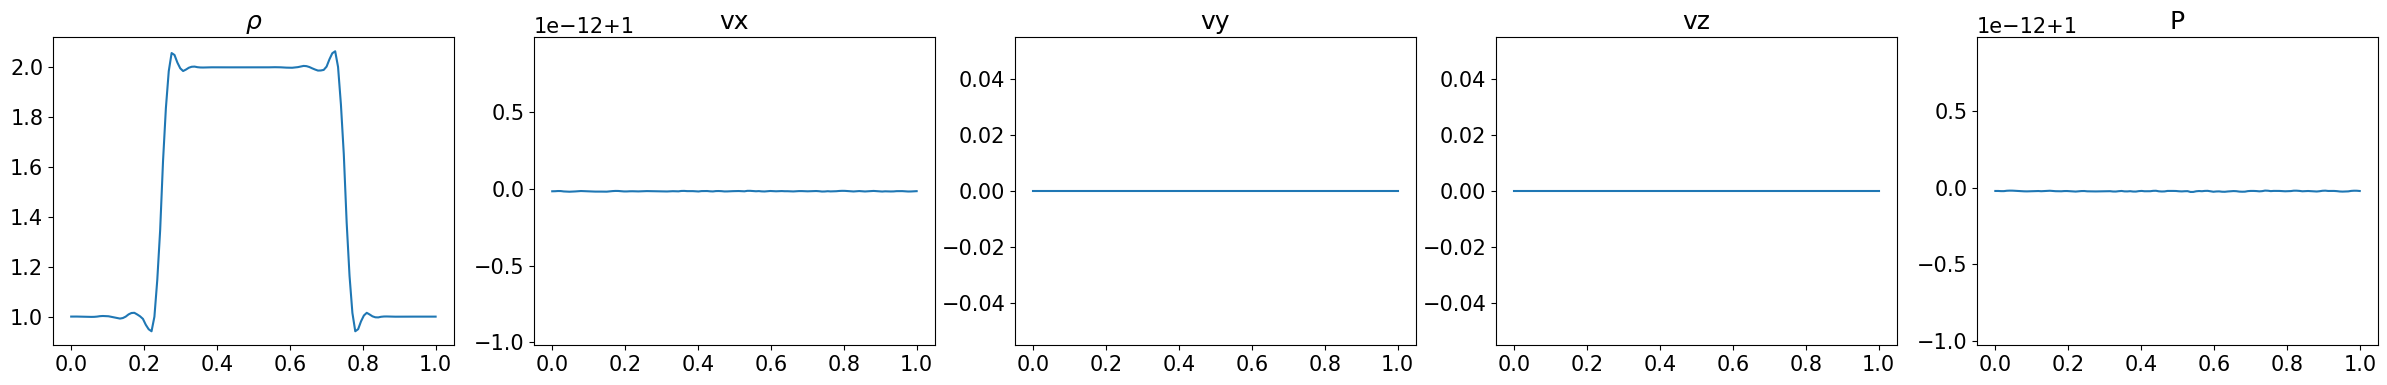

In [26]:
N=32
s = SD_Simulator(p=3,N=(N,),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True,time_integrator="rk3")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

t=1.0, steps taken 474, time taken 0.137, bzcps = 0.0


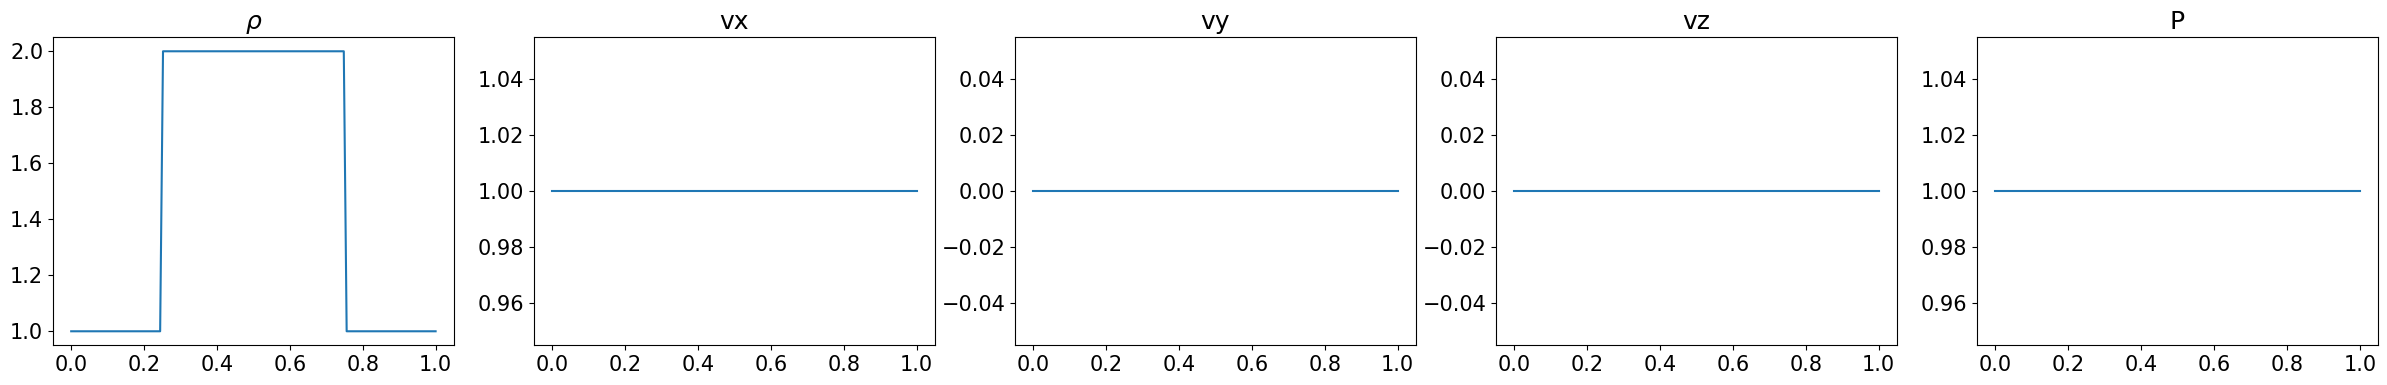

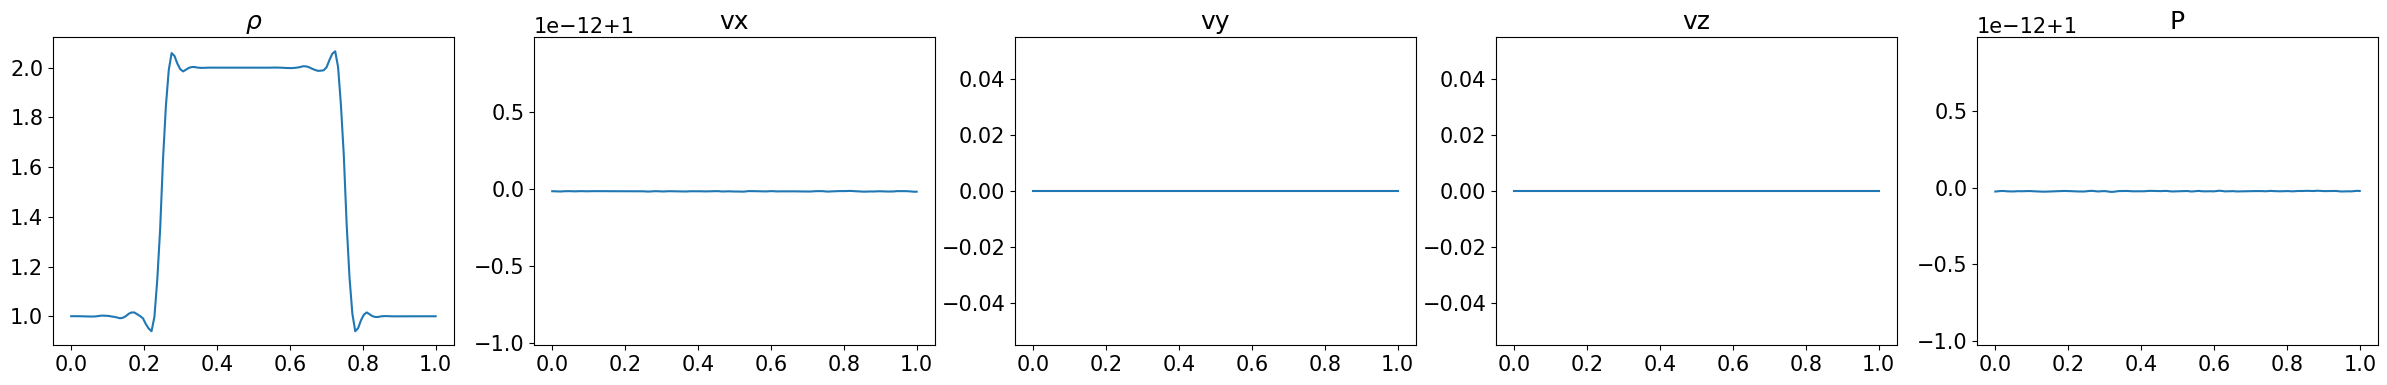

In [27]:
N=32
s = SD_Simulator(p=3,N=(N,),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True,time_integrator="rk4")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

This notebook demonstrates 1D/2D/3D spectral-difference (SD) runs, finite-volume (FV) fallback with blending, and explicit Runge-Kutta time integration via `SDFB_Simulator`.

If `cupy` is not installed, the notebook falls back to CPU (NumPy) execution automatically.

In [ ]:
from sdfb_simulator import SDFB_Simulator

In [ ]:
N=32
s = SDFB_Simulator(p=3,N=(N,),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True)
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

In [ ]:
N=32
s = SDFB_Simulator(p=3,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True)
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

In [ ]:
N=32
s = SDFB_Simulator(p=3,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.6,time_integrator="rk3",use_cupy=True)
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(0.5)
vsd.plot_fields(s,s.dm.W_cv)

In [ ]:
N=16
s = SDFB_Simulator(p=3,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.6,time_integrator="rk3",use_cupy=True,
                   fallback="MUSCL")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1.0)
vsd.plot_fields(s,s.dm.W_cv)

In [ ]:
s.lo_scheme.blending

In [ ]:
N=16
s = SDFB_Simulator(p=3,N=(N,N,N),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True)
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

In [ ]:
N=16
s = SDFB_Simulator(p=3,N=(N,N,N),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True,time_integrator="rk3")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

In [ ]:
N=16
s = SDFB_Simulator(p=3,N=(N,N,N),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True,time_integrator="rk3",fallback="MUSCL")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

In [ ]:
N=16
s = SDFB_Simulator(p=3,N=(N,N,N),init_fct=ic.step_function(),cfl_coeff=0.6,use_cupy=True,time_integrator="rk4")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

# SD+FB

Finite-volume fallback (FB) enabled for robust shock handling.

In [ ]:
N=64
s = SDFB_Simulator(p=3,N=(N,),init_fct=ic.step_function(),cfl_coeff=0.6,update="FV",FB=True,
                     blending=False,use_cupy=True)
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

In [ ]:
N=32
s = SDFB_Simulator(p=3,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.6,update="FV",FB=True,
                     blending=False,use_cupy=True)
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

In [ ]:
N=16
s = SDFB_Simulator(p=3,N=(N,N,N),init_fct=ic.step_function(),cfl_coeff=0.6,update="FV",FB=True,
                     blending=False,use_cupy=True)
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

# SD+FB+Blending

Blending enabled to smooth the transition between SD and FV updates.

In [ ]:
N=64
s = SDFB_Simulator(p=3,N=(N,),init_fct=ic.step_function(),cfl_coeff=0.6,update="FV",FB=True,
                     blending=True,use_cupy=True)
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

In [ ]:
N=32
s = SDFB_Simulator(p=3,N=(N,N),init_fct=ic.step_function(),cfl_coeff=0.6,update="FV",FB=True,
                     blending=True,use_cupy=True)
vsd.plot_fields(s,s.dm.W_cv)
vsd.plot_fields(s,s.dm.U_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

In [ ]:
N=16
s = SDFB_Simulator(p=3,N=(N,N,N),init_fct=ic.step_function(),cfl_coeff=0.6,update="FV",FB=True,
                     blending=True,use_cupy=True)
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

# HLLC (FB)

Finite-volume runs using HLLC and the moncen limiter for sharper discontinuities.

In [ ]:
N=64
s = SDFB_Simulator(p=3,N=(N,),init_fct=ic.step_function(),cfl_coeff=0.6,update="FV",FB=True,
                     blending=True,use_cupy=True,
                     riemann_solver_fv="hllc")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)

# MONCEN (FB)

In [ ]:
N=64
s = SDFB_Simulator(p=3,N=(N,),init_fct=ic.step_function(),cfl_coeff=0.6,update="FV",FB=True,
                     blending=True,use_cupy=True,
                     riemann_solver_fv="hllc",slope_limiter="moncen")
vsd.plot_fields(s,s.dm.W_cv)
s.perform_time_evolution(1)
vsd.plot_fields(s,s.dm.W_cv)